In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [136]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [137]:
print(df.shape)

(1338, 7)


In [138]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [139]:
categorical_features = ['sex','smoker','region']
numerical_features = ['age','bmi','children']

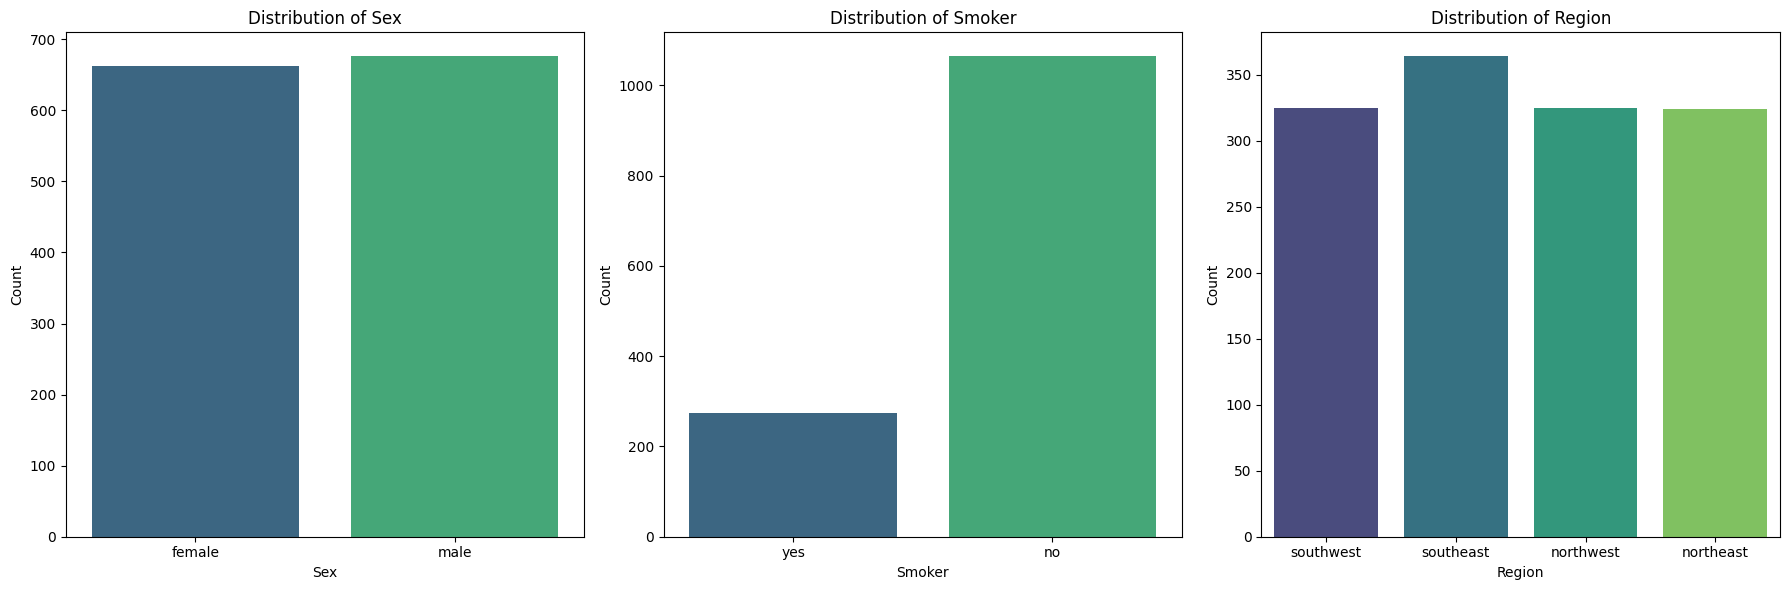

In [140]:
plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_features):
  plt.subplot(1, len(categorical_features), i+1)
  sns.countplot(x=col, data=df, palette='viridis', hue=col, legend=False)
  plt.title(f'Distribution of {col.capitalize()}')
  plt.xlabel(col.capitalize())
  plt.ylabel('Count')
plt.tight_layout()
plt.show()

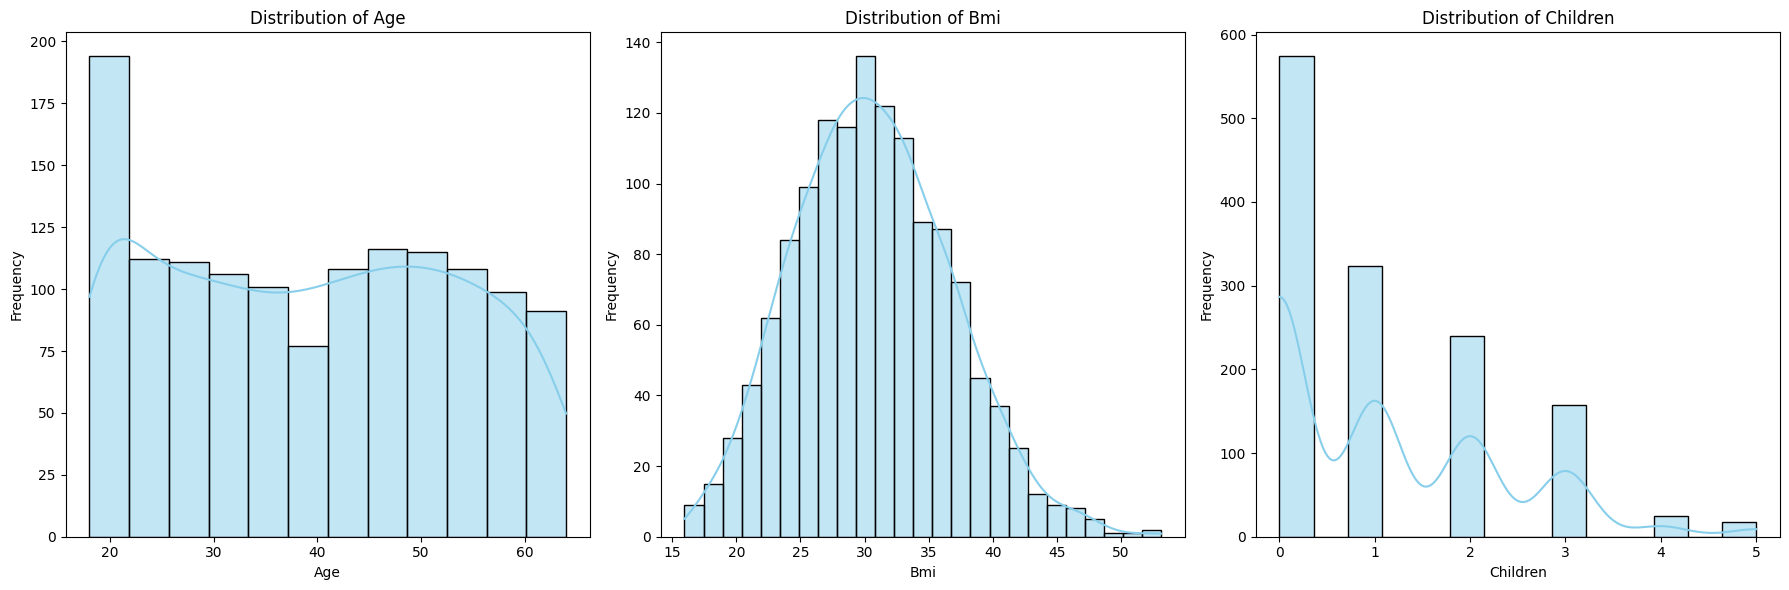

In [141]:
plt.figure(figsize=(18, 6))
for i, col in enumerate(numerical_features):
  plt.subplot(1, len(numerical_features), i+1)
  sns.histplot(df[col], kde=True, color='skyblue')
  plt.title(f'Distribution of {col.capitalize()}')
  plt.xlabel(col.capitalize())
  plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [142]:
X = df.drop('charges',axis=1)
y = df['charges']
print(X)
print("-------------------------")
print(y)

      age     sex     bmi  children smoker     region
0      19  female  27.900         0    yes  southwest
1      18    male  33.770         1     no  southeast
2      28    male  33.000         3     no  southeast
3      33    male  22.705         0     no  northwest
4      32    male  28.880         0     no  northwest
...   ...     ...     ...       ...    ...        ...
1333   50    male  30.970         3     no  northwest
1334   18  female  31.920         0     no  northeast
1335   18  female  36.850         0     no  southeast
1336   21  female  25.800         0     no  southwest
1337   61  female  29.070         0    yes  northwest

[1338 rows x 6 columns]
-------------------------
0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [143]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(y_train.shape)

(1070, 6)
(1070,)


In [144]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(drop='first',sparse_output=False)
ct = ColumnTransformer(
    transformers = [['ohe',encoder,categorical_features]],
    remainder = 'passthrough'
)

ct.fit(X_train)
X_train_encoded = ct.transform(X_train)
X_test_encoded  = ct.transform(X_test)

encoded_cols = ct.named_transformers_['ohe'].get_feature_names_out(categorical_features)
all_cols = list(encoded_cols) + numerical_features

X_train_encoded = pd.DataFrame(X_train_encoded, columns=all_cols)
X_test_encoded  = pd.DataFrame(X_test_encoded,  columns=all_cols)

print(X_train_encoded.head())

   sex_male  smoker_yes  region_northwest  region_southeast  region_southwest  \
0       0.0         0.0               1.0               0.0               0.0   
1       0.0         0.0               0.0               0.0               0.0   
2       0.0         0.0               0.0               1.0               0.0   
3       0.0         0.0               0.0               1.0               0.0   
4       0.0         0.0               1.0               0.0               0.0   

    age    bmi  children  
0  46.0  19.95       2.0  
1  47.0  24.32       0.0  
2  52.0  24.86       0.0  
3  39.0  34.32       5.0  
4  54.0  21.47       3.0  


In [145]:
print(X_test_encoded.head())

   sex_male  smoker_yes  region_northwest  region_southeast  region_southwest  \
0       0.0         0.0               0.0               0.0               0.0   
1       0.0         0.0               1.0               0.0               0.0   
2       0.0         1.0               1.0               0.0               0.0   
3       1.0         0.0               1.0               0.0               0.0   
4       1.0         1.0               1.0               0.0               0.0   

    age     bmi  children  
0  45.0  25.175       2.0  
1  36.0  30.020       0.0  
2  64.0  26.885       0.0  
3  46.0  25.745       3.0  
4  19.0  31.920       0.0  


In [146]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled  = scaler.transform(X_test_encoded)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=all_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=all_cols)

print(X_train_scaled.head())

   sex_male  smoker_yes  region_northwest  region_southeast  region_southwest  \
0 -1.024602   -0.508747          1.783168         -0.599661         -0.572314   
1 -1.024602   -0.508747         -0.560800         -0.599661         -0.572314   
2 -1.024602   -0.508747         -0.560800          1.667609         -0.572314   
3 -1.024602   -0.508747         -0.560800          1.667609         -0.572314   
4 -1.024602   -0.508747          1.783168         -0.599661         -0.572314   

        age       bmi  children  
0  0.472227 -1.756525  0.734336  
1  0.543313 -1.033082 -0.911192  
2  0.898745 -0.943687 -0.911192  
3 -0.025379  0.622393  3.202629  
4  1.040918 -1.504893  1.557100  


In [147]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train_scaled,y_train)
rf.fit(X_train_scaled,y_train)

lr_pred = lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test_scaled)

def evaluate_model(name, y_test, y_pred):
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  R² Score : {r2_score(y_test, y_pred):.4f}")
    print(f"  MAE      : {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"  MSE      : {mean_squared_error(y_test, y_pred):.4f}")
    print(f"  RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

evaluate_model("Linear Regression",        y_test, lr_pred)
evaluate_model("Random Forest Regressor",  y_test, rf_pred)


  Linear Regression
  R² Score : 0.7836
  MAE      : 4181.1945
  MSE      : 33596915.8514
  RMSE     : 5796.2847

  Random Forest Regressor
  R² Score : 0.8653
  MAE      : 2549.0091
  MSE      : 20910896.2458
  RMSE     : 4572.8433


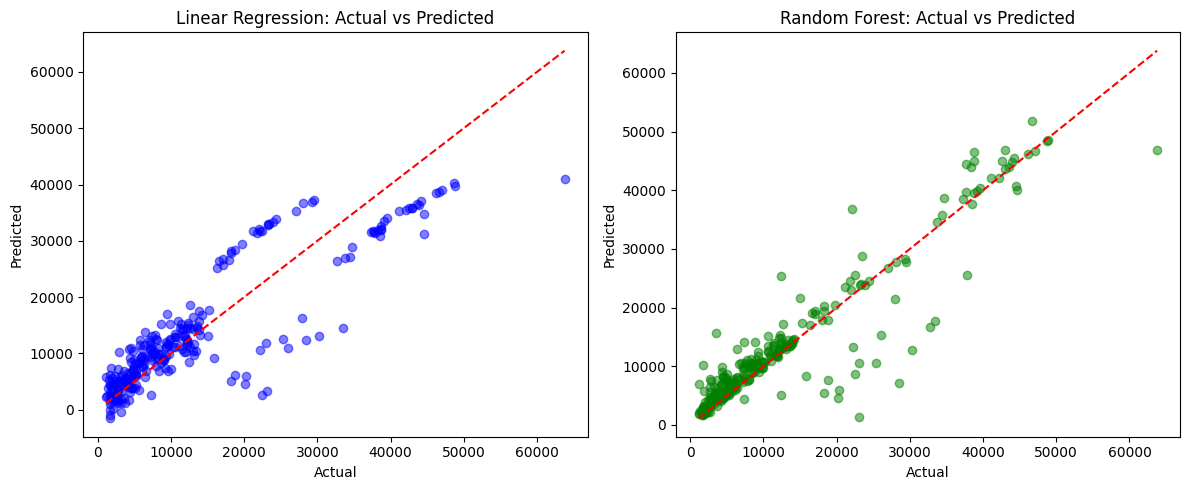

In [148]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual'); plt.ylabel('Predicted')

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual'); plt.ylabel('Predicted')

plt.tight_layout()
plt.show()